In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report,confusion_matrix
import seaborn as sns
import numpy as np


load cifar-10 dataset


In [ ]:
from tensorflow.keras import datasets
(x_train,y_train),(x_test,y_test)=datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 427s 3us/step


In [ ]:
x_train.shape

(50000, 32, 32, 3)

In [ ]:
y_train.shape

(50000, 1)

In [ ]:
x_test.shape

(10000, 32, 32, 3)

In [ ]:
y_test.shape

(10000, 1)

shape of a single image

In [ ]:
print("shape of a single image(x_train[0]:",x_train[0].shape)

shape of a single image(x_train[0]: (32, 32, 3)


normalization

In [ ]:
x_train,x_test=x_train/225.0,x_test/225.0

flatten labels

In [ ]:
y_train=y_train.flatten()
y_test=y_test.flatten()

In [ ]:
class_names=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

plot a sample image

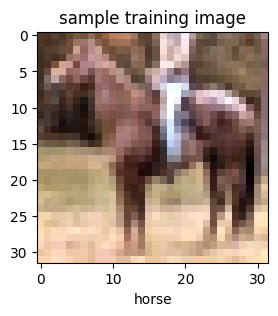

In [ ]:
def plot_sample(x,y,index):
  plt.figure(figsize=(3,3))
  plt.imshow(x[index])
  plt.xlabel(class_names[y[index]])
  plt.title("sample training image")
  plt.show()
plot_sample(x_train,y_train,45000)

build the layer

In [ ]:
model=models.Sequential([
    layers.Conv2D(32,(3,3),activation="relu",input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.Flatten(),
    layers.Dense(64,activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10,activation="softmax")
    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


model compiler

In [ ]:
model.compile(optimizer="adam",
      loss="sparse_categorical_crossentropy",
      metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

train the model

In [ ]:
history=model.fit(x_train,y_train,epochs=10,validation_data=(x_test,y_test),batch_size=64)

NameError: name 'model' is not defined

evaluate the model

In [ ]:
test_loss,test_accuracy=model.evaluate(x_test,y_test)
print("test accuracy:",test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7012 - loss: 0.8636
test accuracy: 0.701200008392334


plot accuracy and loss

<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

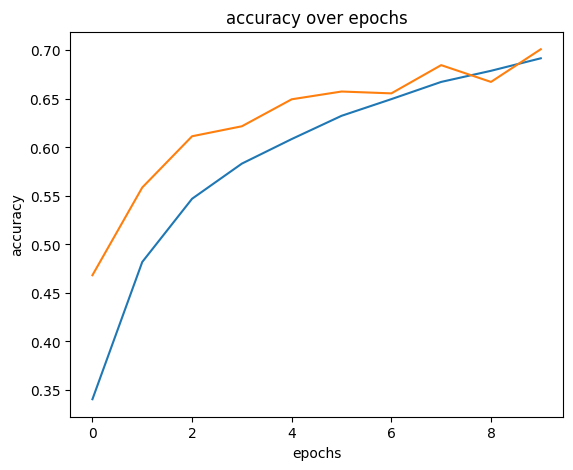

In [ ]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'],label="train accuracy")
plt.plot(history.history["val_accuracy"],label="validation accuracy")
plt.title("accuracy over epochs")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend

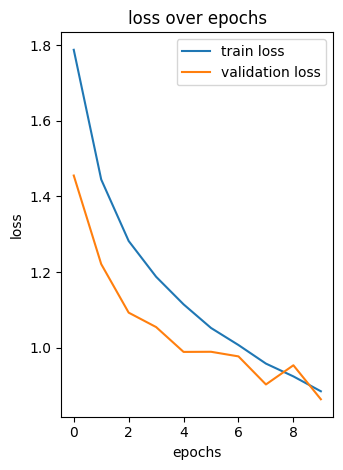

In [ ]:
plt.subplot(1,2,2)
plt.plot(history.history["loss"],label="train loss")
plt.plot(history.history["val_loss"],label="validation loss")
plt.title("loss over epochs")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.show()


prediction on test set

In [ ]:
y_pred_prob=model.predict(x_test)
y_pred_classes=np.argmax(y_pred_prob,axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


confusion matrix

Text(0.5, 1.0, 'confusion matrix')

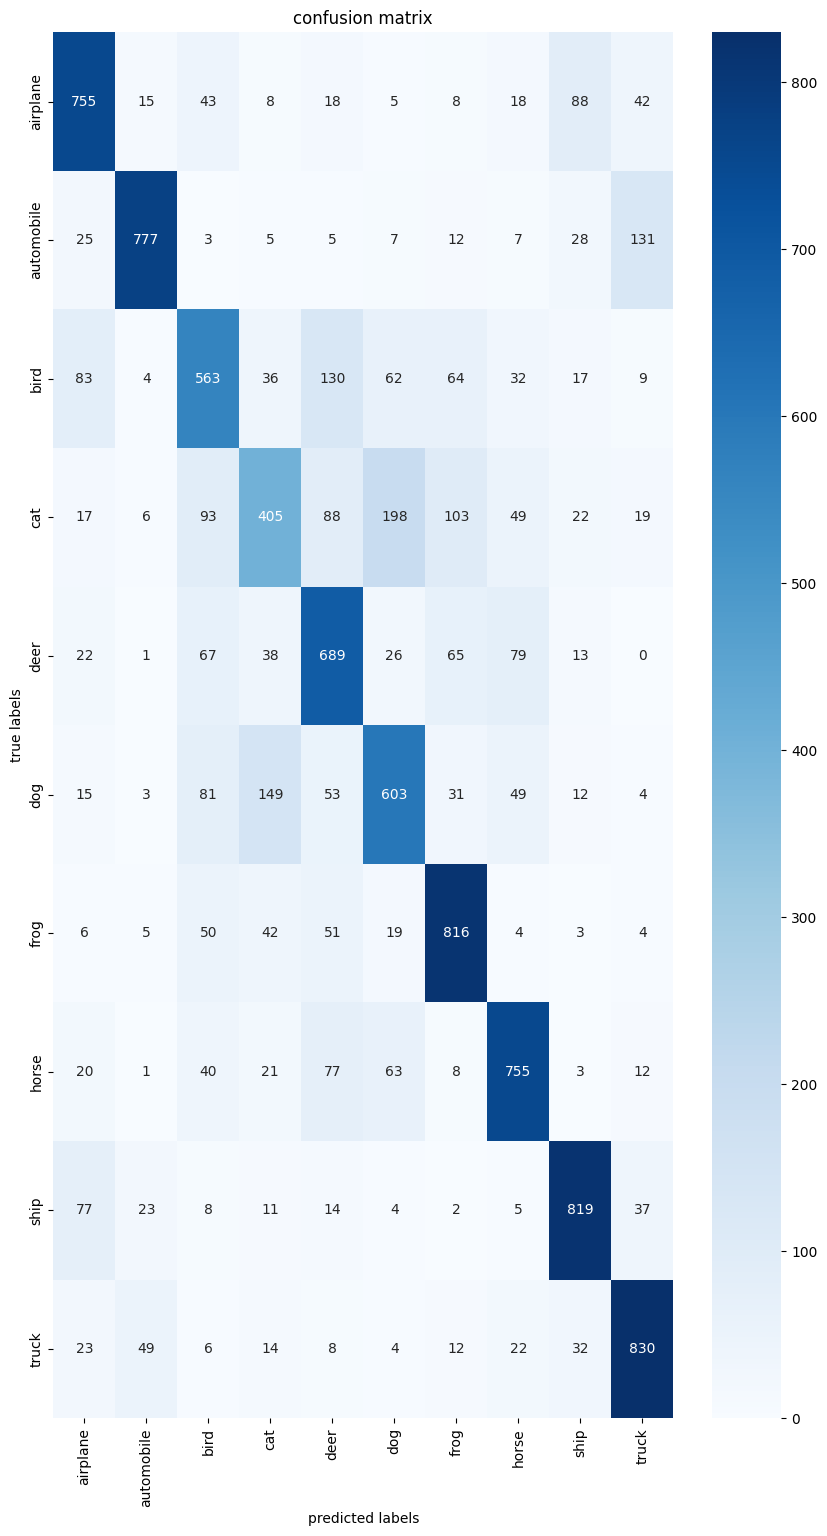

In [ ]:
cm=confusion_matrix(y_test,y_pred_classes)
plt.figure(figsize=(10,18))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=class_names,yticklabels=class_names)
plt.xlabel("predicted labels")
plt.ylabel("true labels")
plt.title("confusion matrix")

In [ ]:
print("\nClassification_report:")
print(classification_report(y_test,y_pred_classes,target_names=class_names))


Classification_report:
              precision    recall  f1-score   support

    airplane       0.72      0.76      0.74      1000
  automobile       0.88      0.78      0.82      1000
        bird       0.59      0.56      0.58      1000
         cat       0.56      0.41      0.47      1000
        deer       0.61      0.69      0.65      1000
         dog       0.61      0.60      0.61      1000
        frog       0.73      0.82      0.77      1000
       horse       0.74      0.76      0.75      1000
        ship       0.79      0.82      0.80      1000
       truck       0.76      0.83      0.80      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



predict and display result for a single test image

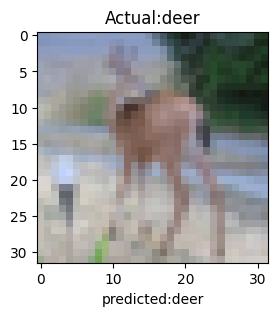

In [ ]:
index=100# you can change this index to any valid index within the set
plt.figure(figsize=(3,3))
plt.imshow(x_test[index])
plt.title(f"Actual:{class_names[y_test[index]]}")
plt.xlabel(f"predicted:{class_names[y_pred_classes[index]]}")
plt.show()